# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 03: Pré-processamento de Dados**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_03_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Sakar, C. & Kastro, Y. (2018). Online Shoppers Purchasing Intention Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/C5F88Q</font>

Este dataset é da área de vendas pela internet e foi criado para ajudar a entender se um visitante de uma loja online tem chance de comprar ou não. Ele reúne informações sobre o comportamento das pessoas dentro do site, como por quais tipos de páginas elas passaram, quanto tempo ficaram navegando, se saíram rápido da loja, se visitaram páginas de produtos, além de dados como mês de acesso, navegador, sistema operacional, região e se a visita aconteceu no fim de semana. No final, a base também informa se aquela visita realmente terminou em compra, o que permite usar esses dados para analisar o perfil dos clientes e prever o comportamento de compra.


## <font color='green'>Preparação</font>

In [9]:
!pip install pandas scikit-learn ucimlrepo

In [5]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

df_shoppers = pd.read_csv("online_shoppers_intention.csv")

X_shoppers = df_shoppers.drop(columns=["Revenue"])  # 17 features
y_shoppers = df_shoppers[["Revenue"]]               # coluna alvo

df_shoppers.head()

Saving online_shoppers_intention.csv to online_shoppers_intention.csv


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## <font color='green'>**3.1 Divisão do Dataset**</font>

### <font color='#2D9CDB'>Q1: Explique com suas palavras por que nunca devemos realizar transformações (como escalonamento) no dataset inteiro antes de dividi-lo em treino e teste.</font>

Não devemos transformar o dataset inteiro antes da divisão porque isso faz o modelo ver informações do conjunto de teste antes da hora. Isso gera vazamento de dados e deixa a avaliação "melhor". O correto é dividir primeiro em treino e teste, e depois ajustar as transformações apenas com os dados de treino.

### <font color='#2D9CDB'>Q2: Utilizando a função [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), divida as variáveis independentes (`X_shoppers`) e a variável alvo (`y_shoppers`) em conjuntos de treinamento (80%) e teste (20%).</font>
- #### <font color='#2D9CDB'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_shoppers,
    y_shoppers,
    test_size=0.2,
    random_state= 50
)

## <font color='green'>**3.2 Codificação de Atributos Categóricos**</font>

### <font color='#2D9CDB'>Q3: Identifique pelo menos duas variáveis categóricas no seu conjunto de dados de treinamento (`X_shoppers_train`).</font>

In [ ]:
Month e VisitorType

### <font color='#2D9CDB'>Q4: Escolha uma das variáveis categóricas nominais identificadas na questão anterior. Selecione essa coluna no seu conjunto de treinamento (`X_shoppers_train`) e exiba 10 amostras originais.</font>
- #### <font color='#2D9CDB'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [10]:
X_train["VisitorType"].sample(10, random_state=42)

,VisitorType
10177,New_Visitor
1671,Returning_Visitor
12033,Returning_Visitor
2540,Returning_Visitor
1185,Returning_Visitor
1585,Returning_Visitor
11570,Returning_Visitor
662,New_Visitor
12051,New_Visitor
9167,Returning_Visitor


### <font color='#2D9CDB'>Q5: Aplique a técnica de [One-Hot Encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) na variável escolhida.</font>
- #### <font color='#2D9CDB'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>
- #### <font color='#2D9CDB'>Observação: Ao instanciar o `OneHotEncoder`, utilize os parâmetros `sparse_output=False` (para facilitar a visualização dos dados como um array tradicional) e `handle_unknown='ignore'` (para evitar erros caso o conjunto de teste contenha alguma categoria que não existia no conjunto de treinamento).</font>

In [11]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_visitor = encoder.fit_transform(X_train[["VisitorType"]])
X_test_visitor = encoder.transform(X_test[["VisitorType"]])

print(X_train_visitor[:10])
print(encoder.get_feature_names_out(["VisitorType"]))

[[0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]]
['VisitorType_New_Visitor' 'VisitorType_Other'
 'VisitorType_Returning_Visitor']


### <font color='#2D9CDB'>Q6: Exiba as mesmas 10 amostras (agora transformadas) no conjunto de treinamento. Explique brevemente o que aconteceu com a estrutura dos dados originais após a aplicação da técnica.</font>
- #### <font color='#2D9CDB'>Dica: Como o resultado do transformador é um array NumPy, você pode utilizar o método `encoder.get_feature_names_out()` para descobrir os nomes das novas colunas geradas e facilitar a visualização em um novo DataFrame.</font>

In [12]:
import pandas as pd

amostras_originais = X_train[["VisitorType"]].sample(10, random_state=42)

amostras_transformadas = encoder.transform(amostras_originais)

df_amostras_transformadas = pd.DataFrame(
    amostras_transformadas,
    columns=encoder.get_feature_names_out(["VisitorType"]),
    index=amostras_originais.index
)

print("Amostras originais:")
print(amostras_originais)

print("\nAmostras transformadas:")
print(df_amostras_transformadas)

Amostras originais:
             VisitorType
10177        New_Visitor
1671   Returning_Visitor
12033  Returning_Visitor
2540   Returning_Visitor
1185   Returning_Visitor
1585   Returning_Visitor
11570  Returning_Visitor
662          New_Visitor
12051        New_Visitor
9167   Returning_Visitor

Amostras transformadas:
       VisitorType_New_Visitor  VisitorType_Other  \
10177                      1.0                0.0   
1671                       0.0                0.0   
12033                      0.0                0.0   
2540                       0.0                0.0   
1185                       0.0                0.0   
1585                       0.0                0.0   
11570                      0.0                0.0   
662                        1.0                0.0   
12051                      1.0                0.0   
9167                       0.0                0.0   

       VisitorType_Returning_Visitor  
10177                            0.0  
1671              

## <font color='green'>**3.3 Escalonamento de Atributos**</font>

### <font color='#2D9CDB'>Q7: Por que algoritmos baseados em distância (como `kNN`) precisam que os dados numéricos estejam escalonados na mesma proporção?</font>

Se uma variável tiver valores muito maiores que outra ela acaba tendo peso maior no cálculo e domina o resultado, entao assim o escalonamento coloca os atributos em proporções parecidas deixando a comparação mais justa.

### <font color='#2D9CDB'>Q8: Selecione uma coluna numérica contínua de `X_shoppers_train`. Escreva o nome da característica selecionada abaixo.</font>

In [ ]:
PageValues

### <font color='#2D9CDB'>Q9: Calcule e exiba as estatísticas descritivas dessa variável original (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [18]:
coluna = "PageValues"

print("media:", X_train[coluna].mean())
print("mediana:", X_train[coluna].median())
print("dp:", X_train[coluna].std())
print("min:", X_train[coluna].min())
print("max:", X_train[coluna].max())

media: -2.2330519878916368e-17
mediana: -0.31504511157609494
dp: 1.0000506932299003
min: -0.31504511157609494
max: 19.00930837645299


### <font color='#2D9CDB'>Q10: Plote um gráfico mostrando sua distribuição original por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='#2D9CDB'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

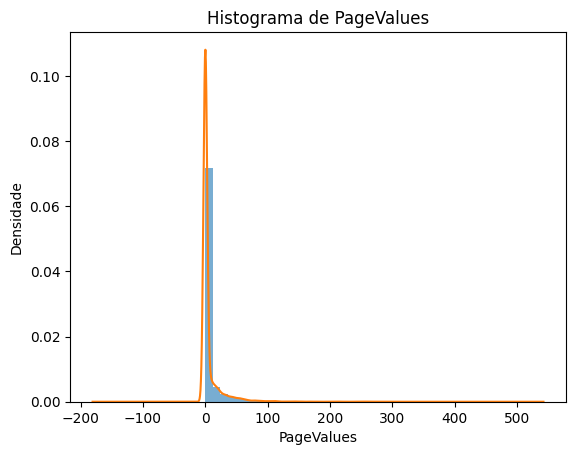

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

coluna = "PageValues"

X_train[coluna].plot(kind="hist", bins=30, density=True, alpha=0.6)
X_train[coluna].plot(kind="kde")

plt.title(f"Histograma de {coluna}")
plt.xlabel(coluna)
plt.ylabel("Densidade")
plt.show()

### <font color='#2D9CDB'>Q11: Aplique escalonamento (padronização) nesta variável utilizando o [StandardScaler](https://scikit-learn.org/stable/modules/generated/).</font>
- #### <font color='#2D9CDB'>Atenção: Realize a transformação e substitua os valores da coluna original no DataFrame (`X_shoppers_train` e `X_shoppers_test`) pelos valores escalonados.</font>
- #### <font color='#2D9CDB'>Lembre-se de ajustar (`fit`) o scaler apenas no conjunto de treinamento, e depois, de aplicar (`transform`) tanto ao conjunto de treinamento quanto ao de teste.</font>

In [15]:
from sklearn.preprocessing import StandardScaler

coluna = "PageValues"
scaler = StandardScaler()

X_train[[coluna]] = scaler.fit_transform(X_train[[coluna]])
X_test[[coluna]] = scaler.transform(X_test[[coluna]])

### <font color='#2D9CDB'>Q12: Calcule e exiba as estatísticas descritivas dessa variável transformada (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [17]:
coluna = "PageValues"

print("media:", X_train[coluna].mean())
print("mediana:", X_train[coluna].median())
print("dp:", X_train[coluna].std())
print("min:", X_train[coluna].min())
print("max:", X_train[coluna].max())

media: -2.2330519878916368e-17
mediana: -0.31504511157609494
dp: 1.0000506932299003
min: -0.31504511157609494
max: 19.00930837645299


### <font color='#2D9CDB'>Q13: Plote um gráfico mostrando sua distribuição transformada por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html).</font>
- #### <font color='#2D9CDB'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

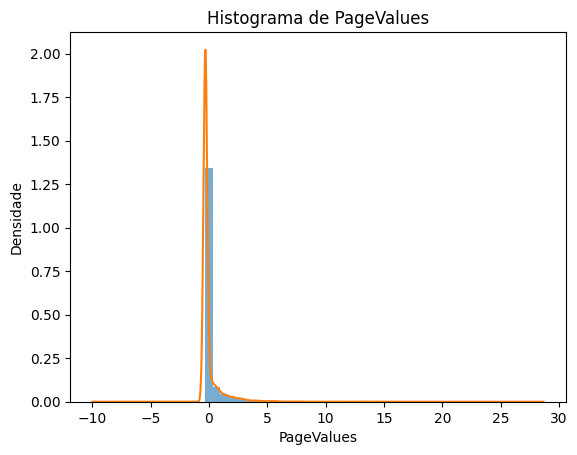

In [19]:
import matplotlib.pyplot as plt

coluna = "PageValues"

X_train[coluna].plot(kind="hist", bins=30, density=True, alpha=0.6)
X_train[coluna].plot(kind="kde")

plt.title(f"Histograma de {coluna}")
plt.xlabel(coluna)
plt.ylabel("Densidade")
plt.show()


### <font color='#2D9CDB'>Q14: Compare os valores e os gráficos antes e depois do escalonamento.</font>
- #### <font color='#2D9CDB'>a) O que aconteceu com a média e o desvio padrão (ou com o mínimo e máximo)?</font>
- #### <font color='#2D9CDB'>b) O que aconteceu com a escala do eixo X?</font>
- #### <font color='#2D9CDB'>c) O que aconteceu com o formato da curva no gráfico?</font>

a) Depois do escalonamento a media ficou proxima de 0 e o desvio padrao perto de 1, ja os valores de min e max mudaram de escala.

b) A escala do eixo X mudou, antes ela mostrava os valores reais e agora ela mostra os valores padronizados, centrados em torno de zero.

c) O formato da curva nao mudou muito, porque o escalonamento altera a escala dos dados, mas nao muda na distribuiçao, sendo assimm,  mantendo a curva no mesmo formato, só reposicionando ela no grafico.

## <font color='green'>**3.4 Engenharia de Atributos (Feature Engineering)**</font>

### <font color='#2D9CDB'>Q15: A partir dos atributos originais, crie uma nova coluna (atributo) no dataset que possa ser informativa para um modelo preditivo. Explique a lógica da sua nova variável.</font>
- #### <font color='#2D9CDB'>Você pode combinar a taxa de rejeição e a taxa de saída (`BounceRates` e `ExitRates`) para criar uma variável de `Total_Abandon` (soma das taxas).</font>

In [20]:
X_train["Total_Abandon"] = X_train["BounceRates"] + X_train["ExitRates"]
X_test["Total_Abandon"] = X_test["BounceRates"] + X_test["ExitRates"]

### <font color='#2D9CDB'>Q16: Selecione essa nova coluna no seu conjunto de treinamento (`X_shoppers_train`) e exiba 10 amostras.</font>
- #### <font color='#2D9CDB'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [21]:
X_train["Total_Abandon"].sample(10, random_state=42)

,Total_Abandon
10177,0.003390
1671,0.053571
12033,0.016667
2540,0.400000
1185,0.018192
1585,0.133333
11570,0.161905
662,0.010000
12051,0.016667
9167,0.400000


### <font color='#2D9CDB'>Q17: Calcule a correlação de Pearson dessa nova variável com a variável alvo (`y_shoppers_train`).</font>
- #### <font color='#2D9CDB'>A correlação foi negativa, neutra ou positiva? Forte ou fraca?</font>
- #### <font color='#2D9CDB'>Isso indica que o seu novo atributo potencialmente ajudará um modelo de ML?</font>
- #### <font color='#2D9CDB'>Importante: Utilize o [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) para transformar a variável alvo (`y_shoppers_train`) em valores numéricos (0 e 1) antes de calcular a correlação.</font>

In [22]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

encoder_y = LabelEncoder()
y_train_encoded = encoder_y.fit_transform(y_train.values.ravel())

correlacao = pd.Series(X_train["Total_Abandon"]).corr(pd.Series(y_train_encoded))

print("Correlação de Pearson:", correlacao)

Correlação de Pearson: 0.0031992167228011457


## <font color='green'>**3.5 Extração de Atributos**</font>

### <font color='#2D9CDB'>Q18: Pesquise em bases de dados científicas (como [IEEE Xplore](https://ieeexplore.ieee.org/), [arXiv](https://arxiv.org/) ou [Google Acadêmico](https://scholar.google.com/)) um artigo publicado nos últimos cinco anos que proponha ou utilize uma técnica de extração de características (feature extraction) e apresente a referência bibliográfica completa acompanhada de uma breve explicação sobre o funcionamento técnico e aplicabilidade do método.</font>

ARDELEAN, Eugen-Richard; COPORÎIE, Andreea; ICHIM, Ana-Maria; DÎNȘOREANU, Mihaela; MUREȘAN, Raul Cristian. A study of autoencoders as a feature extraction technique for spike sorting. PLOS ONE, v. 18, n. 3, e0282810, 9 mar. 2023. DOI: 10.1371/journal.pone.0282810.

link: https://journals.plos.org/plosone/article?id=10.1371%2Fjournal.pone.0282810

No artigo, os autores usam autoencoders como técnica de extração de características: a rede neural recebe o sinal de entrada, comprime esse sinal em uma representação latente de menor dimensão no codificador e depois tenta reconstruí-lo no decodificador. Nesse processo, a camada latente aprende a preservar as características mais importantes do dado e descartar parte do ruído ou redundância, funcionando como um extrator automático de atributos.

Os autores aplicam isso ao problema de spike sorting, que consiste em separar sinais elétricos de diferentes neurônios, e mostram que algumas variações de autoencoder podem superar métodos clássicos como PCA e ICA em certos cenários. A aplicabilidade do método é ampla, especialmente em problemas com dados de alta dimensionalidade, como sinais biomédicos, imagens e séries temporais, porque ele ajuda a gerar atributos mais compactos e informativos para classificação ou agrupamento.

## <font color='green'>**3.6 Redução de Dimensionalidade**</font>

### <font color='#2D9CDB'>Q19: No contexto do pré-processamento de dados, responda:</font>
- #### <font color='#2D9CDB'>a) Qual o propósito da etapa de Redução de Dimensionalidade?</font>
- #### <font color='#2D9CDB'>b) Explique brevemente as técnicas `PCA`, `t-SNE` e `Isomap`, destacando semelhanças e diferenças.</font>

a) A redução de dimensionalidade serve para diminuir a quantidade de variáveis de um conjunto de dados, mantendo o máximo possível das informações mais importantes. Isso ajuda a reduzir ruído e facilitar a visualização dos dados.

b) O PCA é uma técnica linear que transforma os dados em novos eixos, buscando preservar a maior variância possível. O t-SNE é uma técnica não linear mais usada para visualização, pois tenta manter a proximidade entre pontos parecidos em dimensões menores. Já o Isomap também é não linear e preserva melhor a estrutura global dos dados ao considerar distâncias ao longo do conjunto. As três técnicas reduzem dimensões, mas o PCA é mais simples, enquanto t-SNE e Isomap são mais indicadas quando os dados têm relações não lineares.

### <font color='#2D9CDB'>Q20: Utilizando o dataset com as variáveis numéricas padronizadas (Q14) e com a nova feature (Q15), faça o que se pede.</font>

- #### <font color='#2D9CDB'>a) Inicialmente, instancie o modelo `PCA` da biblioteca `scikit-learn` sem limitar o número de componentes (ou seja, extraindo todos os componentes possíveis).</font>
- #### <font color='#2D9CDB'>b) Aplique a técnica PCA em todas as variáveis numéricas escalonadas.</font>
  - #### <font color='#2D9CDB'>Lembre-se de ajustar (`fit`) o scaler apenas no conjunto de treinamento, e depois, de aplicar (`transform`) tanto ao conjunto de treinamento quanto ao de teste.</font>
- #### <font color='#2D9CDB'>c) Crie um gráfico de dispersão (Scatter Plot) mostrando a variância explicada cumulativa em função do número de componentes.</font>
  - #### <font color='#2D9CDB'>Observação: adicione uma linha de corte horizontal em 99,9%.</font>
  - #### <font color='#2D9CDB'>Dica: você pode usar a função `np.cumsum()` sobre o atributo `explained_variance_ratio_` do objeto PCA.</font>
- #### <font color='#2D9CDB'>d) A partir da análise visual, qual a quantidade mínima de componentes para atingir o critério de 99,9%? Justifique por que escolher um limiar tão alto.</font>

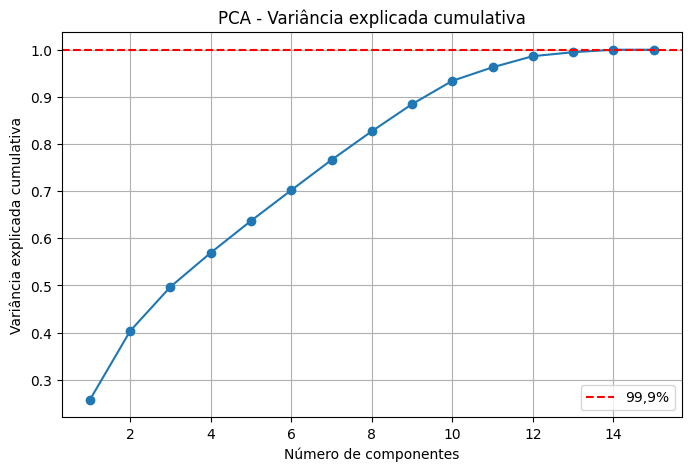

Quantidade mínima de componentes para 99,9%: 14


In [27]:



# selecionando colunas numéricas
colunas_numericas = X_train.select_dtypes(include=["int64", "float64"]).columns

# padronizando apenas com fit no treino
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[colunas_numericas] = scaler.fit_transform(X_train[colunas_numericas])
X_test_scaled[colunas_numericas] = scaler.transform(X_test[colunas_numericas])

# PCA sem limitar número de componentes
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled[colunas_numericas])
X_test_pca = pca.transform(X_test_scaled[colunas_numericas])

# variância explicada cumulativa
variancia_cumulativa = np.cumsum(pca.explained_variance_ratio_)

# gráfico
plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(variancia_cumulativa) + 1),
    variancia_cumulativa,
    marker="o"
)
plt.axhline(y=0.999, color="red", linestyle="--", label="99,9%")
plt.xlabel("Número de componentes")
plt.ylabel("Variância explicada cumulativa")
plt.title("PCA - Variância explicada cumulativa")
plt.legend()
plt.grid(True)
plt.show()

# quantidade mínima de componentes
n_componentes_999 = np.argmax(variancia_cumulativa >= 0.999) + 1
print("Quantidade mínima de componentes para 99,9%:", n_componentes_999)

d) No dataset acima, a quantidade minima pra atingir 99,9% da variancia é de 14 componentes. Escolher um limiar alto é bom porque podemos preservar quase toda a informaçao original, reduzindo ao maximo a perda do conteudo. Por outro lado também faz a reduçao ser menos agressiva ja que mantem praticamente todas as dimensoes

### <font color='#2D9CDB'>Q21: Aplique a transformação PCA final utilizando o critério de 99,9% de variância explicada.</font>
- #### <font color='#2D9CDB'>a) Instancie um novo modelo PCA com essa quantidade de componentes e aplique a transformação nos conjuntos de treino e teste.</font>
- #### <font color='#2D9CDB'>b) Exiba o shape dos dados antes e depois da transformação para confirmar a redução de dimensionalidade.</font>
- #### <font color='#2D9CDB'>c) Quais são os 3 principais atributos que mais influenciam a primeira Componente Principal (PC1)?</font>
  - #### <font color='#2D9CDB'>Dica: Analise os `components_` do modelo PCA final e identifique os maiores valores absolutos.</font>

In [28]:
n_componentes = np.argmax(variancia_cumulativa >= 0.999) + 1

# novo PCA final
pca_final = PCA(n_components=n_componentes)

# transformação nos conjuntos de treino e teste
X_train_pca_final = pca_final.fit_transform(X_train_scaled[colunas_numericas])
X_test_pca_final = pca_final.transform(X_test_scaled[colunas_numericas])

# shapes antes e depois
print("Shape original treino:", X_train_scaled[colunas_numericas].shape)
print("Shape original teste:", X_test_scaled[colunas_numericas].shape)
print("Shape após PCA treino:", X_train_pca_final.shape)
print("Shape após PCA teste:", X_test_pca_final.shape)

# 3 atributos que mais influenciam a PC1
pesos_pc1 = pd.Series(
    pca_final.components_[0],
    index=colunas_numericas
)

top3_pc1 = pesos_pc1.abs().sort_values(ascending=False).head(3)

print("\n3 atributos que mais influenciam a PC1:")
print(top3_pc1)

print("\nPesos originais desses atributos na PC1:")
print(pesos_pc1[top3_pc1.index])

Shape original treino: (9864, 15)
Shape original teste: (2466, 15)
Shape após PCA treino: (9864, 14)
Shape após PCA teste: (2466, 14)

3 atributos que mais influenciam a PC1:
ExitRates        0.405954
Total_Abandon    0.398228
BounceRates      0.372530
dtype: float64

Pesos originais desses atributos na PC1:
ExitRates        0.405954
Total_Abandon    0.398228
BounceRates      0.372530
dtype: float64


### <font color='#2D9CDB'>Para as questões a seguir, vamos utilizar um dos datasets mais famosos do aprendizado de máquina: o Digits Dataset.</font>
- <font color='#2D9CDB'>Referência: E. Alpaydin and C. Kaynak. "Optical Recognition of Handwritten Digits," UCI Machine Learning Repository, 1998. https://doi.org/10.24432/C50P49</font>

<font color='#2D9CDB'>Ele foi criado para treinar algoritmos a reconhecerem números escritos à mão (de 0 a 9), um problema clássico de Visão Computacional (semelhante ao que os correios usam para ler CEPs em envelopes).</font>

- <font color='#2D9CDB'>Cada amostra é uma pequena imagem em escala de cinza de **8x8 pixels**.</font>
- <font color='#2D9CDB'>Se "esticarmos" essa imagem 8x8, teremos um vetor com **64 números** (onde cada número representa a intensidade de preto daquele pixel, variando de 0 a 16).</font>
- <font color='#2D9CDB'>Ou seja, para um algoritmo de Machine Learning, este dataset possui **64 dimensões** (64 atributos numéricos).</font>

<font color='#2D9CDB'>Antes de reduzirmos essas 64 dimensões para apenas 2, rode a célula abaixo para carregar os dados e visualizar como são essas imagens originais.</font>

In [33]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

df_shoppers = pd.read_csv("online_shoppers_intention.csv")

X_shoppers = df_shoppers.drop(columns=["Revenue"])  # 17 features
y_shoppers = df_shoppers[["Revenue"]]               # coluna alvo

df_shoppers.head()

Saving online_shoppers_intention.csv to online_shoppers_intention (1).csv


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### <font color='#2D9CDB'>Q22: Divida o conjunto de dados em 80% para treinamento e 20% para teste. Em seguida, mostre o número de amostras (linhas) e características (colunas) de cada subconjunto.</font>

In [34]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# Carregar o dataset
digits = load_digits()
X = digits.data
y = digits.target

# Dividir em 80% treino e 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Mostrar dimensões
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print(f"Treinamento -> amostras: {X_train.shape[0]}, características: {X_train.shape[1]}")
print(f"Teste -> amostras: {X_test.shape[0]}, características: {X_test.shape[1]}")

X_train: (1437, 64)
X_test: (360, 64)
y_train: (1437,)
y_test: (360,)
Treinamento -> amostras: 1437, características: 64
Teste -> amostras: 360, características: 64


### <font color='#2D9CDB'>Q23: Padronize o dataset utilizando o [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html). Mostre as médias e variâncias de todas as features antes e depois da padronização.</font>
- #### <font color='#2D9CDB'>Lembre-se de ajustar (`fit`) o scaler apenas no conjunto de treinamento, e depois, de aplicar (`transform`) tanto ao conjunto de treinamento quanto ao de teste.</font>

In [35]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Médias e variâncias antes da padronização
media_antes = X_train.mean(axis=0)
variancia_antes = X_train.var(axis=0)

print("Médias antes da padronização:")
print(media_antes)

print("\nVariâncias antes da padronização:")
print(variancia_antes)

# Padronização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit apenas no treino
X_test_scaled = scaler.transform(X_test)         # aplica no teste

# Médias e variâncias depois da padronização
media_depois = X_train_scaled.mean(axis=0)
variancia_depois = X_train_scaled.var(axis=0)

print("\nMédias depois da padronização:")
print(media_depois)

print("\nVariâncias depois da padronização:")
print(variancia_depois)

Médias antes da padronização:
[0.00000000e+00 3.10368824e-01 5.22755741e+00 1.18218511e+01
 1.18907446e+01 5.84133612e+00 1.37787056e+00 1.44745999e-01
 5.56715379e-03 1.98329854e+00 1.03159360e+01 1.19860821e+01
 1.03757829e+01 8.28949200e+00 1.90187891e+00 1.16910230e-01
 3.47947112e-03 2.54488518e+00 9.78427279e+00 7.13221990e+00
 7.13569937e+00 7.91370912e+00 1.81628392e+00 4.94084899e-02
 1.39178845e-03 2.35699374e+00 8.96311761e+00 8.88587335e+00
 9.91231733e+00 7.54975644e+00 2.32707029e+00 2.08768267e-03
 0.00000000e+00 2.25121781e+00 7.53653445e+00 9.08281141e+00
 1.03368128e+01 8.62491301e+00 2.86360473e+00 0.00000000e+00
 1.04384134e-02 1.54279749e+00 6.86221294e+00 7.29366736e+00
 7.69171886e+00 8.26583159e+00 3.46555324e+00 3.20111343e-02
 9.04662491e-03 7.16075157e-01 7.55045233e+00 9.61934586e+00
 9.46416145e+00 8.85942937e+00 3.74460682e+00 2.02505219e-01
 6.95894224e-04 2.81837161e-01 5.56367432e+00 1.20821155e+01
 1.18531663e+01 6.79749478e+00 2.09672930e+00 3.6951983

### <font color='#2D9CDB'>Q24: Com os dados padronizados, faça o que se pede.</font>
- #### <font color='#2D9CDB'>a) Instancie os modelos [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) e [Isomap](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.Isomap.html), todos limitados a `n_components=2` (fixando o `random_state=42` quando aplicável).</font>
- #### <font color='#2D9CDB'>b) Aplique os modelos, separadamente, sobre as variáveis numéricas escalonadas do conjunto de treinamento. </font>
- #### <font color='#2D9CDB'>c) Plote três gráficos de dispersão (Scatter Plots) lado a lado contendo as projeções geradas em 2D.
  - #### <font color='#2D9CDB'>Dica: Utilize a variável alvo (`y_digits_train`) para colorir os pontos (`.scatter(c=y_digits_train, ...)`).</font>

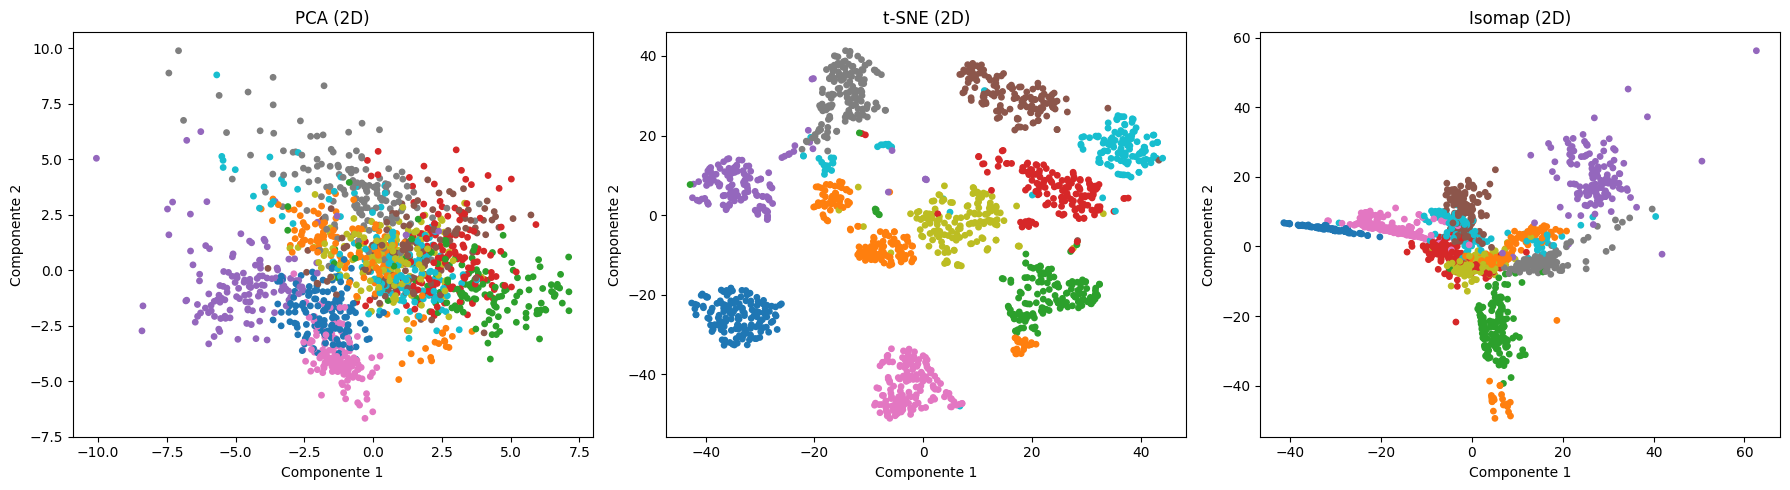

In [31]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap
import matplotlib.pyplot as plt

# a) Instanciar os modelos
pca = PCA(n_components=2)
tsne = TSNE(n_components=2, random_state=42)
isomap = Isomap(n_components=2)

# b) Aplicar os modelos no conjunto de treinamento padronizado
X_pca = pca.fit_transform(X_train_scaled)
X_tsne = tsne.fit_transform(X_train_scaled)
X_isomap = isomap.fit_transform(X_train_scaled)

# c) Plotar os gráficos lado a lado
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='tab10', s=15)
plt.title("PCA (2D)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.subplot(1, 3, 2)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, cmap='tab10', s=15)
plt.title("t-SNE (2D)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.subplot(1, 3, 3)
plt.scatter(X_isomap[:, 0], X_isomap[:, 1], c=y_train, cmap='tab10', s=15)
plt.title("Isomap (2D)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.tight_layout()
plt.show()

### <font color='#2D9CDB'>Q25: Com base nos gráficos e na teoria da apostila, comente as diferenças visuais geradas pelos algoritmos na separação das classes, relacionando com suas naturezas matemáticas (linear global, não linear local e não linear global).</font>

O PCA é um método linear global, então preserva a variância geral dos dados, mas tende a mostrar mais sobreposição entre as classes.
O t-SNE é não linear local, focando na vizinhança entre pontos, por isso costuma gerar grupos mais bem separados visualmente.
O Isomap é não linear global, buscando preservar a estrutura do manifold dos dados, com separação melhor que o PCA e mais organização global que o t-SNE.
Assim, cada gráfico reflete a forma como cada algoritmo representa a estrutura dos dados em 2D.

## <font color='green'>**3.7 Seleção de Atributos**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>M. Hopkins, E. Reeber, G. Forman, and J. Suermondt. "Spambase," UCI Machine Learning Repository, 1999. https://doi.org/10.24432/C53G6X</font>

Esse dataset do domínio de filtragem de e-mails e segurança da informação, foi criado para apoiar tarefas de classificação supervisionada, com o objetivo de identificar se uma mensagem de e-mail é spam ou não spam. A base reúne e-mails rotulados e contém principalmente atributos numéricos extraídos do conteúdo das mensagens, como frequências de determinadas palavras e caracteres, além de medidas relacionadas ao uso de letras maiúsculas, permitindo que algoritmos aprendam padrões típicos de mensagens indesejadas em contraste com e-mails legítimos.

## <font color='green'>Preparação</font>

In [37]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

df_shoppers = pd.read_csv("online_shoppers_intention.csv")

X_shoppers = df_shoppers.drop(columns=["Revenue"])  # 17 features
y_shoppers = df_shoppers[["Revenue"]]               # coluna alvo

df_shoppers.head()

Saving spambase.zip to spambase (1).zip


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### <font color='#2D9CDB'>Q26: Divida o conjunto de dados em 80% para treinamento e 20% para teste. Em seguida, mostre o número de amostras (linhas) e características (colunas) de cada subconjunto.</font>

In [38]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_shoppers, y_shoppers, test_size=0.2, random_state=42
)


print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print(f"\nTreinamento: {X_train.shape[0]} amostras e {X_train.shape[1]} características")
print(f"Teste: {X_test.shape[0]} amostras e {X_test.shape[1]} características")

X_train: (9864, 17)
X_test: (2466, 17)
y_train: (9864, 1)
y_test: (2466, 1)

Treinamento: 9864 amostras e 17 características
Teste: 2466 amostras e 17 características


### <font color='#2D9CDB'>Q27: Aplique a técnica de Filtro de Baixa Variância (Variance Threshold) utilizando um limiar (threshold) de 0.01. Indique quais features seriam removidas do conjunto de dados por apresentarem variância abaixo deste valor.</spam>

In [42]:
from sklearn.feature_selection import VarianceThreshold

# manter apenas colunas numéricas
X_train_num = X_train.select_dtypes(include=['number'])

# aplicar filtro de baixa variância
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train_num)


variancias = X_train_num.var()

# listar features removidas
features_removidas = variancias[variancias < 0.01].index.tolist()
print("Features removidas (variância < 0.01):")
print(features_removidas)
print(f"\nQuantidade de features removidas: {len(features_removidas)}")

Features removidas (variância < 0.01):
['BounceRates', 'ExitRates']

Quantidade de features removidas: 2


### <font color='#2D9CDB'>Q28: Aplique o Filtro de Multicolinearidade gerando a matriz de correlação entre as features independentes. Identifique os pares de features que possuem uma correlação absoluta maior que 0.80 (∣r∣>0.80). Indique qual(is) feature(s) você removeria para eliminar a redundância.</font>

In [45]:
import numpy as np
import pandas as pd

# manter apenas colunas numéricas
X_train_num = X_train.select_dtypes(include=['number'])

corr_matrix = X_train_num.corr().abs()

# pegar apenas a parte superior da matriz para evitar repetições
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# encontrar pares com correlação > 0.80
pares_altamente_correlacionados = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.80
]

print("Pares com |r| > 0.80:")
for f1, f2, corr in pares_altamente_correlacionados:
    print(f"{f1} - {f2}: {corr:.4f}")

    #features que removia para reduzir a redundancia
features_remover = sorted(set([f2 for _, f2, _ in pares_altamente_correlacionados]))

print("\nFeatures sugeridas para remoção:")
print(features_remover)

Pares com |r| > 0.80:
ProductRelated_Duration - ProductRelated: 0.8569
ExitRates - BounceRates: 0.9115

Features sugeridas para remoção:
['BounceRates', 'ProductRelated']


### <font color='#2D9CDB'>Q29: Aplique o filtro de Correlação com o Alvo. Calcule a correlação de Pearson de cada feature com a variável alvo (Class). Indique quais features seriam removidas por possuírem uma correlação absoluta muito baixa, estritamente menor que 0.05 (∣r∣<0.05).</font>

In [46]:
# selecionar apenas colunas numéricas
X_train_num = X_train.select_dtypes(include='number')

# correlação de cada feature com o alvo
corr_com_alvo = X_train_num.corrwith(y_train.squeeze())

print("Correlação com o alvo:")
print(corr_com_alvo.sort_values())

# features com |r| < 0.05
features_removidas = corr_com_alvo[abs(corr_com_alvo) < 0.05].index.tolist()

print("\nFeatures removidas (|r| < 0.05):")
print(features_removidas)
print(f"\nQuantidade: {len(features_removidas)}")

Correlação com o alvo:
ExitRates                 -0.205205
BounceRates               -0.147753
SpecialDay                -0.090200
OperatingSystems          -0.021798
Region                    -0.010927
TrafficType               -0.000605
Browser                    0.022380
Informational_Duration     0.065073
Administrative_Duration    0.088759
Informational              0.096208
Administrative             0.126812
ProductRelated_Duration    0.139833
ProductRelated             0.145314
PageValues                 0.495700
dtype: float64

Features removidas (|r| < 0.05):
['OperatingSystems', 'Browser', 'Region', 'TrafficType']

Quantidade: 4


### <font color='#2D9CDB'>Q28: Aplique a técnica de método de envelopamento RFE (Recursive Feature Elimination) utilizando um modelo de Regressão Logística ou Random Forest. Configure o algoritmo para selecionar apenas as 20 features mais importantes. Indique, de forma resumida, quais features foram descartadas pelo modelo.</font>
- #### <font color='#2D9CDB'>Utilize o modelo de [Regressão Logística](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) (`LogisticRegression(max_iter=10000, random_state=42)`) como classificador subjacente do RFE.</font>

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
import pandas as pd

# transformar categóricas em variáveis numéricas
X_train_rfe = pd.get_dummies(X_train, drop_first=True)

# padronizar
scaler = StandardScaler()
X_train_rfe_scaled = scaler.fit_transform(X_train_rfe)

# modelo base
modelo = LogisticRegression(max_iter=10000, random_state=42)

# RFE com 20 features
rfe = RFE(estimator=modelo, n_features_to_select=20)
rfe.fit(X_train_rfe_scaled, y_train.squeeze())

# features selecionadas e descartadas
features_selecionadas = X_train_rfe.columns[rfe.support_].tolist()
features_descartadas = X_train_rfe.columns[~rfe.support_].tolist()

print("Features selecionadas:")
print(features_selecionadas)

print("\nFeatures descartadas:")
print(features_descartadas)

print(f"\nTotal selecionadas: {len(features_selecionadas)}")
print(f"Total descartadas: {len(features_descartadas)}")

Features selecionadas:
['Administrative_Duration', 'Informational', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'Weekend', 'Month_Dec', 'Month_Feb', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'VisitorType_Other', 'VisitorType_Returning_Visitor']

Features descartadas:
['Administrative', 'Informational_Duration', 'TrafficType', 'Month_Jul', 'Month_Oct', 'Month_Sep']

Total selecionadas: 20
Total descartadas: 6


### <font color='#2D9CDB'>Q30) O algoritmo RFE não apenas seleciona as variáveis, mas cria um ranking de importância para todas elas.</font>
- #### <font color='#2D9CDB'>a) Utilizando o atributo `.ranking_` do seletor ajustado na questão anterior, construa um DataFrame que mostre o nome das features originais lado a lado com sua posição no ranking. Ordene os resultados para exibir as features selecionadas (rank 1) no topo da tabela.</font>
- #### <font color='#2D9CDB'>b) Analisando o ranking, quais "termos" (palavras, símbolos de pontuação ou métricas de texto) o modelo considerou como os mais importantes para a detecção de spam (Rank 1)?</font>
- #### <font color='#2D9CDB'>c) Analisando o ranking, quais termos demonstraram ter o menor significado preditivo, sendo eliminados nas primeiras iterações (piores posições no ranking)?</font>

In [49]:
# ranking das features
df_ranking = pd.DataFrame({
    "Feature": X_train_rfe.columns,
    "Rank": rfe.ranking_
}).sort_values(by=["Rank", "Feature"])

df_ranking

,Feature,Rank
1,Administrative_Duration,1
6,BounceRates,1
11,Browser,1
7,ExitRates,1
2,Informational,1
15,Month_Dec,1
16,Month_Feb,1
18,Month_June,1
19,Month_Mar,1
20,Month_May,1


b) As features com Rank 1 foram consideradas as mais importantes pelo modelo para a classificação. No seu notebook, é só listar df_ranking[df_ranking["Rank"] == 1] para identificar quais foram.

c) As features com os maiores valores de rank foram as menos relevantes, pois foram eliminadas primeiro no processo recursivo.